🚀 Welcome to your second mission! In this section you will use your gained information about our datasets to create a model that predicts the amount of damage for a car accident represented by the variable **ClaimAmount**. 


##### 🔍 <span style="color: #003366; font-weight: bold;">Your goal</span>

Try to find the best model possible, represented by the lowest *Mean Squared Error* you can get. To do this, these are your tasks: 

**Tasks**: 

 1.1 ) Discuss with your team which features might have an impact on **ClaimAmount** and you want to use within your model.

 1.2 ) Create several models (at least 4) with different features. 

 2 ) Have a look at the plots. Do you think that the created models are good? Explain your answer. (✨**1 point**)

<img src="../images/modelling_sis.png" width="40"/> **Hint**: If you want to now what the *Mean Squared Error* is, have a look in the FAQ.


**Ratings**:

🥇 The team with the least *Mean Squared Error* will receive **7** points

🥈 The team with the second least *Mean Squared Error* will receive **4** points

🥉 The team with the third least *Mean Squared Error* will receive **2** points


<img src="../images/modelling_sis.png" width="40"/> **Hint**:
Extend your models by interactions or non linear relations.
- A*B indicates that there is a interaction between A and B
- np.log(A), np.exp(A), A**2 indicated a non linear realtion


<img src="../images/modelling_sis.png" width="40"/> **Hint**: Have a closer lookup to https://www.statsmodels.org/dev/example_formulas.html


🚀 But now let's start again.

Again we will import some Python packages that we will use for modelling and initialize the DataFrame *models_overview* where we keep the evaluation of your created models.

In [1]:
# Import required packages
import pandas as pd 
from sklearn.model_selection import train_test_split
from utils import train_evaluate_and_visualize_model


#Init model_overview once
models_overview = pd.DataFrame(columns=['Model', 'Formula', 'MSE'])

Have a look at the data again, you will have to figure out which of these features you want to use in your models:

- **IDPol:** Unique ID for each policy, used to link to severity data set
- **VehPower:** Car power; 1 is lowest, 8 is highest power
- **VehAge:** Car age, in years
- **VehBrand:** Car brand
- **VehGas:** Fuel type (Regular or Diesel)
- **DriverBirthDate:** The Birth Date of the Driver
- **BonusMalus:** BonusMalus rating, <100 represents a good driver, >100 represents a bad driver
- **Region:** Policy region in France
- **Density:** Density rating, number of inhabitants per km^2
- **Area:** Groups of the above Density rating

    | Area Code  | Density in km^2  |
    |------------|------------------|
    | **A**  | 1-50 |
    | **B**  | 50-100 |
    | **C**  | 100-500 |
    | **D**  | 500-2000 |
    | **E**  | 2001-9850 |
    | **F**  | 10008-27000 |

Next we will load the merged dataset that was created in the first section

In [5]:
# Load Dataset
url = "./../data/sample_solution/claims_policies.csv"
data = pd.read_csv(url)
data.head()


,IDpol,ClaimAmount,Area,VehPower,VehAge,BonusMalus,VehBrand,VehGas,Density,Region,DriverBirthDate,DrivAge
0,1552,995.20,D,11,0,56,B12,Diesel,778,R22,1985-12-22,39
1,1010996,1128.12,E,4,1,50,B12,Regular,2354,R11,1976-04-26,49
2,4024277,1851.11,D,4,2,106,B12,Regular,570,R31,1992-08-01,32
3,4007252,1204.00,C,4,1,57,B12,Regular,288,R73,1975-12-29,49
4,4046424,1204.00,F,12,0,50,B12,Diesel,27000,R11,1988-02-29,37


In [6]:
data.describe() #pusheb

,IDpol,ClaimAmount,VehPower,VehAge,BonusMalus,Density,DrivAge
count,2.641700e+04,2.641700e+04,26417.000000,26417.000000,26417.000000,26417.000000,26417.000000
mean,2.281045e+06,2.266556e+03,6.464133,7.355642,65.233940,2015.103721,45.117500
std,1.583334e+06,2.938597e+04,2.017397,5.165096,20.147937,4163.792942,14.682901
min,1.390000e+02,1.000000e+00,4.000000,0.000000,50.000000,2.000000,18.000000
25%,1.086065e+06,6.871400e+02,5.000000,3.000000,50.000000,115.000000,34.000000
50%,2.134079e+06,1.172000e+03,6.000000,7.000000,55.000000,522.000000,45.000000
75%,3.184413e+06,1.212290e+03,7.000000,11.000000,76.000000,2252.000000,54.000000
max,6.113971e+06,4.075401e+06,15.000000,99.000000,228.000000,27000.000000,95.000000


In [4]:
data.describe() #Großschäden noch weg
print(len(data[data["ClaimAmount"]>10000]))
data = data[data["ClaimAmount"]<10000] #extra-modell dafür

478


Split your dataset in train and test data.

**Hint**: If you want to know why we are doing this, have a look into the FAQ

In [4]:
train, test = train_test_split(data,  test_size=0.2, random_state=41)

### 1. Model

                 MODEL PERFORMANCE                 
Mean Squared Error (MSE): 1473112.33


Added model_1 to the overview.
Congratulations! model_1 is your best model with the lowest MSE until now: 1473112.33.


Model,Formula,MSE
model_1,ClaimAmount ~ VehPower + VehAge + DrivAge + BonusMalus + Density +Area + VehBrand + VehGas + Region,1473112.33


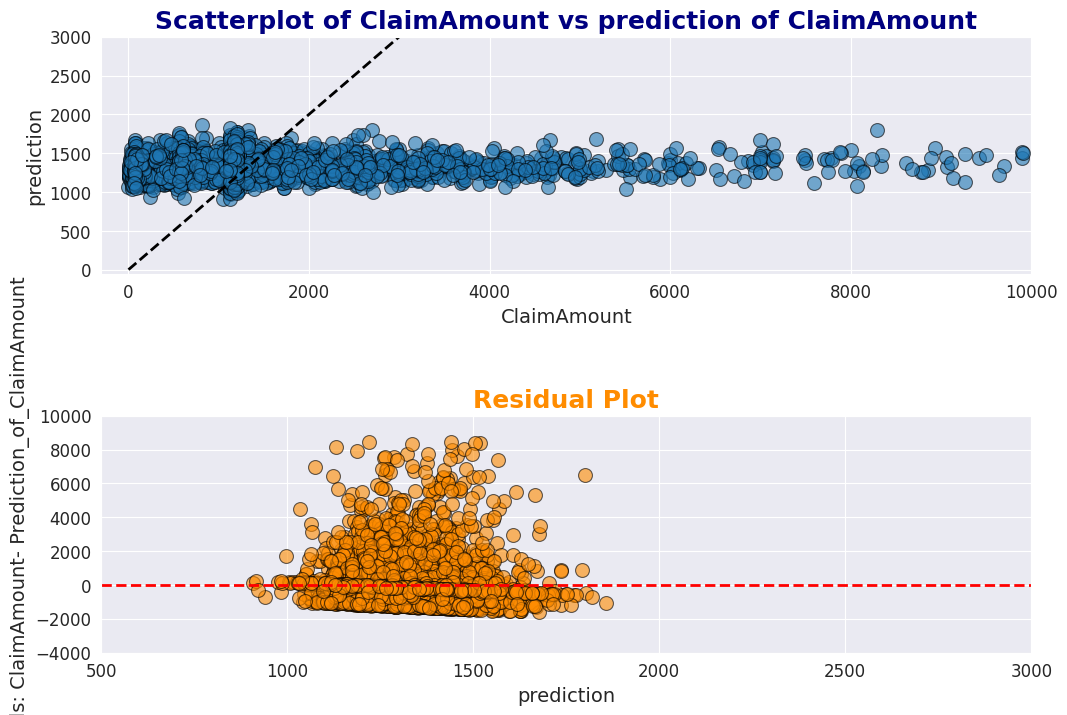

In [5]:
formula = "ClaimAmount ~ VehPower + VehAge + DrivAge + BonusMalus + Density +Area + VehBrand + VehGas + Region" 


models_overview = train_evaluate_and_visualize_model(train = train, test = test, formula = formula, models_overview = models_overview)

#Kommentar dass sie sich die Grafiken anschauen sollen, Gerade linie --> FAQ

Now you trained your first model!

Look at the mse, try to find a model, that has a **lower** mse than the first model. 

Can you find the model with the lowest mse?

### 2. Model 

Now it is you turn to change the model variables!

Therefore change the variables in the "formula" variable. 
Please leave "ClaimAmount ~ " at the beginning, this determines that we want to predict the Claim Amount. 

                 MODEL PERFORMANCE                 
Mean Squared Error (MSE): 1471710.19
Added model_2 to the overview.
Congratulations! model_2 is your best model with the lowest MSE until now: 1471710.19.


Model,Formula,MSE
model_1,ClaimAmount ~ VehPower + VehAge + DrivAge + BonusMalus + Density +Area + VehBrand + VehGas + Region,1473112.33
model_2,ClaimAmount ~ Region + DrivAge + BonusMalus,1471710.19


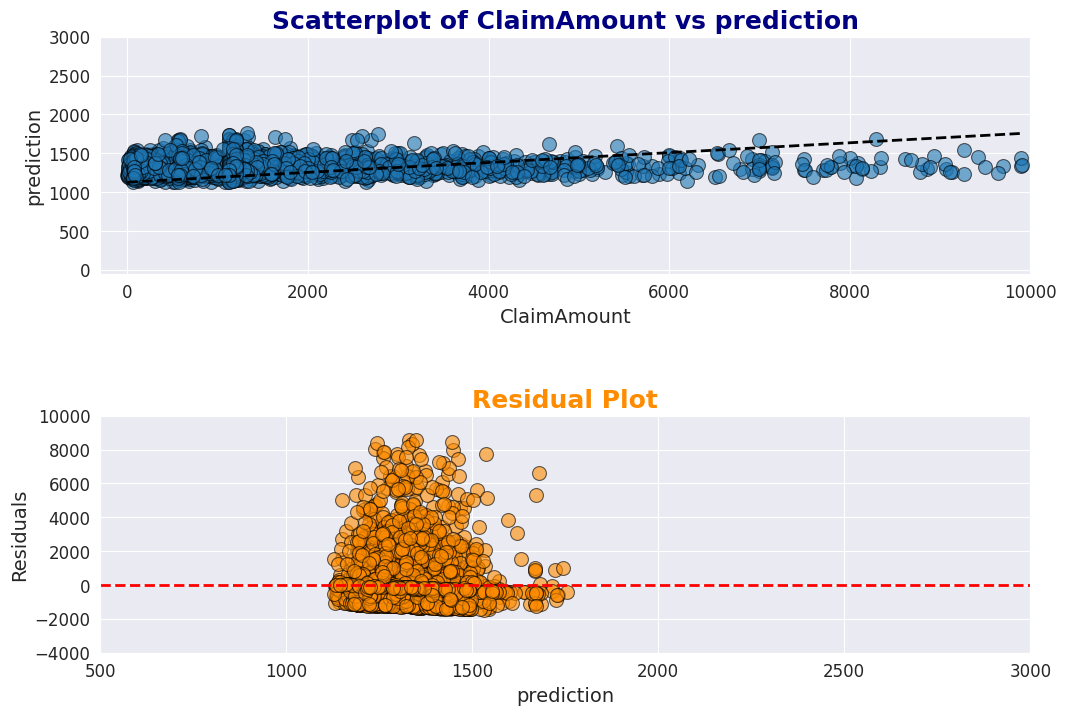

,Model,Formula,MSE
0,model_1,ClaimAmount ~ VehPower + VehAge + DrivAge + Bo...,1473112.33
1,model_2,ClaimAmount ~ Region + DrivAge + BonusMalus,1471710.19


In [13]:
formula = "ClaimAmount ~ Region + DrivAge + BonusMalus" 


train_evaluate_and_visualize_model(train = train, test = test, formula = formula, models_overview = models_overview)

### 3.Model

In [ ]:
formula = "ClaimAmount ~ INSERT_YOUR_VARIABLES_HERE" 


model = smf.glm(formula, data=train, family=sm.families.Gamma(link=sm.families.links.Log())) 
results = model.fit()

#predict

test["prediction"] = results.predict(test)


#evaluate
mse = mean_squared_error(test["ClaimAmount"], test["prediction"])

print("=" * 50)  
print("                 MODEL PERFORMANCE                 ")  
print("=" * 50)  
print(f"Mean Squared Error (MSE): {mse:.2f}")  
print("=" * 50)

#visualisation
plot_scatter_and_residuals(test, "ClaimAmount", "prediction")

#add model to models_overview
models_overview = add_model_to_overview(models_overview, formula=formula, mse=mse)

display(HTML(models_overview.to_html(escape=False, index=False)))

### 4.Model

In [ ]:
formula = "ClaimAmount ~ INSERT_YOUR_VARIABLES_HERE" 


model = smf.glm(formula, data=train, family=sm.families.Gamma(link=sm.families.links.Log())) 
results = model.fit()

#predict

test["prediction"] = results.predict(test)


#evaluate
mse = mean_squared_error(test["ClaimAmount"], test["prediction"])

print("=" * 50)  
print("                 MODEL PERFORMANCE                 ")  
print("=" * 50)  
print(f"Mean Squared Error (MSE): {mse:.2f}")  
print("=" * 50)

#visualisation
plot_scatter_and_residuals(test, "ClaimAmount", "prediction")

#add model to models_overview
models_overview = add_model_to_overview(models_overview, formula=formula, mse=mse)

display(HTML(models_overview.to_html(escape=False, index=False)))

Copy the above code and paste it in a new cell if you want to create more models.